In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, accuracy_score

### Шаг 1. Извлечение важности признаков

In [3]:
df = pd.read_csv('https://code.s3.yandex.net/datasets/ds_s15t3_exoplanet.csv')

X = df.drop(columns=['label'])
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=627
)

In [5]:
# оптимальные гиперпараметры, найденные с помощью Optuna
best_params = {
    'n_estimators': 193, 
    'max_depth': 25, 
    'max_features': 'log2', 
    'max_samples': 0.9363545585152561
}

# обучаем модель
best_model = RandomForestClassifier(
    **best_params,
    random_state=627
)
best_model.fit(X_train, y_train)

# извлекаем важности признаков
importances = best_model.feature_importances_
print(importances)

[0.05987313 0.04772659 0.0841926  0.06962931 0.0592259  0.02640974
 0.02695914 0.02714558 0.06872971 0.12595571 0.08928282 0.05273992
 0.05023568 0.05901469 0.04631955 0.10655992]


### Шаг 2. Объединение важности с названиями признаков

In [6]:
# сохраним признаки в DataFrame
feature_importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': importances
})

# отсортируем по убыванию важности
feature_importances = feature_importances.sort_values(by='importance', ascending=False)

print(feature_importances)

           feature  importance
9    planet_radius    0.125956
15        lc_time0    0.106560
10  orbital_period    0.089283
2              pc3    0.084193
3               ra    0.069629
8          kep_mag    0.068730
0              pc1    0.059873
4              dec    0.059226
13     star_radius    0.059015
11       star_teff    0.052740
12       star_logg    0.050236
1              pc2    0.047727
14       star_mass    0.046320
7            k_mag    0.027146
6            h_mag    0.026959
5            j_mag    0.026410


### Шаг 3. Визуализация важности с помощью seaborn

C:\Users\mikhail.yakunin\AppData\Local\Temp\ipykernel_12552\1515039081.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


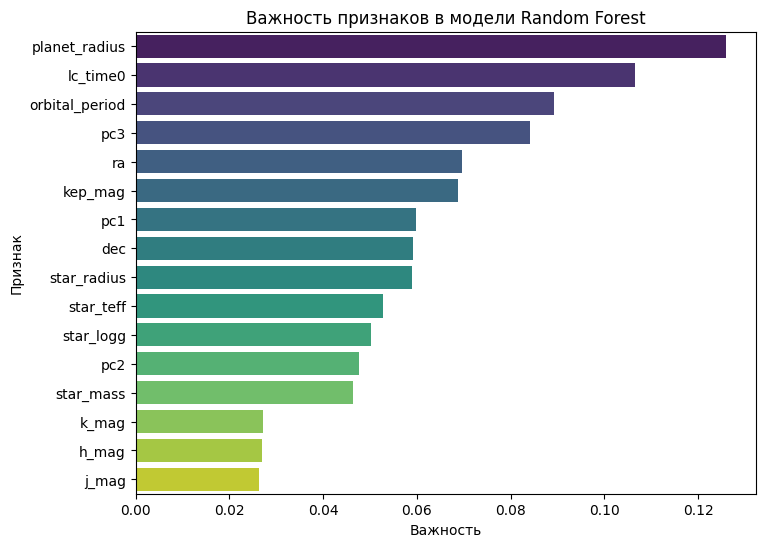

In [16]:
plt.figure(figsize=(8, 6))
sns.barplot(
    data=feature_importances,
    x='importance',
    y='feature',
    palette='viridis'
)

plt.title('Важность признаков в модели Random Forest')
plt.xlabel('Важность')
plt.ylabel('Признак')
plt.show()